## Este sí produce los beneficios bien

In [15]:
import pandas as pd

In [16]:
estadistica = 'promedio'
T=100
G =36


In [17]:
df=pd.read_csv(f'symmetric/{G}redes{estadistica}/resultados_Estimaciones_{T}.csv')

df["cluster"] = pd.to_numeric(df["cluster"], errors="coerce")
df=df[df["cluster"].notna()]



In [18]:
import ast
import numpy as np
import pandas as pd

# =========================================================
# 1) Parser robusto para columnas que vienen como listas
# =========================================================
def _to_array24(x):
    if isinstance(x, np.ndarray):
        arr = x.astype(float).reshape(-1)
    elif isinstance(x, list):
        arr = np.asarray(x, dtype=float).reshape(-1)
    elif isinstance(x, str):
        arr = np.asarray(ast.literal_eval(x), dtype=float).reshape(-1)
    else:
        raise ValueError(f"No pude convertir a array: {type(x)}")

    if arr.size != 24:
        raise ValueError(f"Esperaba longitud 24 y llegó {arr.size}")
    return arr


def _safe_float(x, default=0.0):
    try:
        v = float(x)
        if np.isfinite(v):
            return v
        return default
    except:
        return default


# =========================================================
# 2) Construir juego para un solo día
# =========================================================
def build_juego_from_day(df_day, bid_col="est_uni"):
    """
    df_day: subconjunto de un solo día
    bid_col: columna que usarás como oferta/bid
             por ejemplo 'est_uni', 'est_dis' o 'precio_d'
    """
    df_day = df_day.copy()

    # demanda diaria de 24 horas: tomo la primera no nula
    demand_val = None
    for x in df_day["daily_reman_demand"]:
        if pd.notna(x):
            demand_val = x
            break
    if demand_val is None:
        raise ValueError("No encontré daily_reman_demand para este día")

    demanda24 = _to_array24(demand_val)

    juego = {
        "I": np.asarray(df_day["id_planta"].astype(int).tolist(), dtype=int),
        "demanda": demanda24,
    }

    meta_cols = [
        "CodigoPlanta", "phi", "precio_d", "Fecha", "cluster",
        "id_planta", "daily_reman_demand", "Grupo", "est_uni", "est_dis"
    ]

    for _, row in df_day.iterrows():
        pid = int(row["id_planta"])

        juego[pid] = {
            "beta": _safe_float(row[bid_col], default=0.0),
            "available_q": _to_array24(row["available_q"]),
        }

        for col in meta_cols:
            if col in row.index:
                juego[pid][col] = row[col]

    return juego


# =========================================================
# 3) Aplanar equilibrio a nivel planta-día
# =========================================================
def flatten_eq_daily(eq):
    rows = []

    pricing = eq["pricing"]
    price24_sys = eq["price24"]

    for pid in eq["I"]:
        pid = int(pid)
        x = eq[pid]

        q = np.asarray(x["cantidades_despachadas"], dtype=float).reshape(24)
        p = np.asarray(x["precio24"], dtype=float).reshape(24)

        row = {
            "Fecha": x.get("Fecha"),
            "id_planta": x.get("id_planta", pid),
            "CodigoPlanta": x.get("CodigoPlanta"),
            "Grupo": x.get("Grupo"),
            "cluster": x.get("cluster"),
            "phi": x.get("phi"),
            "precio_d": x.get("precio_d"),
            "est_uni": x.get("est_uni"),
            "est_dis": x.get("est_dis"),
            "bid": x["beta"],
            "pricing": pricing,
            "cantidades_despachadas": q.tolist(),
            "precio24": p.tolist(),
            "price24_sistema": np.asarray(price24_sys, dtype=float).tolist(),
            "sumaq": float(q.sum()),
            "ingreso_total": float((q * p).sum()),
        }
        rows.append(row)

    out = pd.DataFrame(rows)
    if "Fecha" in out.columns:
        out["Fecha"] = pd.to_datetime(out["Fecha"])
    return out


# =========================================================
# 4) Expandir a nivel planta-día-hora
# =========================================================
def explode_dispatch_hourly(df_daily_eq):
    rows = []

    for _, row in df_daily_eq.iterrows():
        q = np.asarray(row["cantidades_despachadas"], dtype=float).reshape(24)
        p = np.asarray(row["precio24"], dtype=float).reshape(24)
        ps = np.asarray(row["price24_sistema"], dtype=float).reshape(24)

        for h in range(24):
            rows.append({
                "Fecha": row["Fecha"],
                "hora": h,
                "id_planta": row["id_planta"],
                "CodigoPlanta": row["CodigoPlanta"],
                "Grupo": row["Grupo"],
                "cluster": row["cluster"],
                "phi": row["phi"],
                "pricing": row["pricing"],
                "bid": row["bid"],
                "cantidad_despachada": float(q[h]),
                "precio_pagado": float(p[h]),
                "precio_sistema": float(ps[h]),
                "ingreso_hora": float(q[h] * p[h]),
            })

    out = pd.DataFrame(rows)
    if "Fecha" in out.columns:
        out["Fecha"] = pd.to_datetime(out["Fecha"])
    return out

import numpy as np

def compute_equilibrio_dispatch(juego: dict, pricing: str = "uniform", unmet_price="max_accepted"):
    """
    unmet_price:
      - número (float): usa ese precio si no hay dispatch
      - "max_accepted": si no hay dispatch, usa max bid positivo del sistema (si existe; si no, 0)
    """
    pricing = pricing.lower().strip()
    if pricing not in {"uniform", "pay_as_bid"}:
        raise ValueError("pricing must be 'uniform' or 'pay_as_bid'")

    # ids
    if "I" in juego:
        plant_ids = [int(x) for x in np.asarray(juego["I"]).reshape(-1)]
    else:
        plant_ids = [k for k in juego.keys() if isinstance(k, (int, np.integer))]

    if len(plant_ids) == 0:
        raise ValueError("No plant ids found in juego")

    demand24 = np.asarray(juego["demanda"], dtype=float).reshape(24)
    bids = np.array([float(juego[pid]["beta"]) for pid in plant_ids], dtype=float)
    avail_mat = np.vstack([
        np.asarray(juego[pid]["available_q"], dtype=float).reshape(24)
        for pid in plant_ids
    ])

    I = len(plant_ids)
    disp_mat = np.zeros((I, 24), dtype=float)
    price24 = np.zeros(24, dtype=float)

    # merit order: solo bids positivos
    active = bids > 0
    order = np.array([], dtype=int)
    if np.any(active):
        order = np.where(active)[0][np.argsort(bids[active], kind="mergesort")]

    max_bid_pos = float(np.max(bids[active])) if np.any(active) else 0.0

    for h in range(24):
        remaining = float(max(demand24[h], 0.0))
        if remaining <= 0:
            price24[h] = 0.0
            continue

        av_h = np.maximum(avail_mat[:, h], 0.0)
        last_bid = None
        any_dispatch = False

        for i in order:
            if remaining <= 0:
                break
            take = min(av_h[i], remaining)
            if take > 0:
                disp_mat[i, h] = take
                remaining -= take
                any_dispatch = True
                last_bid = float(bids[i])

        if any_dispatch:
            price24[h] = float(last_bid)
        else:
            if unmet_price == "max_accepted":
                price24[h] = max_bid_pos
            else:
                price24[h] = float(unmet_price)

    if pricing == "uniform":
        precio_mat = np.where(disp_mat > 0.0, price24.reshape(1, 24), 0.0)
    else:
        precio_mat = np.where(disp_mat > 0.0, bids.reshape(I, 1), 0.0)

    eq = {
        "I": np.array(plant_ids, dtype=int),
        "demanda": demand24.copy(),
        "pricing": pricing,
        "price24": price24.copy(),
    }

    meta_cols = [
        "CodigoPlanta", "phi", "precio_d", "Fecha", "cluster",
        "id_planta", "daily_reman_demand", "Grupo", "est_uni", "est_dis"
    ]

    for idx, pid in enumerate(plant_ids):
        q = disp_mat[idx, :].copy()

        eq[pid] = {
            "beta": float(bids[idx]),
            "available_q": avail_mat[idx, :].copy(),
            "cantidades_despachadas": q,
            "precio24": precio_mat[idx, :].copy(),
            "sumaq": float(q.sum()),
        }

        if isinstance(juego.get(pid, {}), dict):
            for col in meta_cols:
                if col in juego[pid]:
                    val = juego[pid][col]
                    if isinstance(val, (list, tuple, np.ndarray)):
                        eq[pid][col] = np.asarray(val).copy()
                    else:
                        eq[pid][col] = val

        if "id_planta" not in eq[pid]:
            eq[pid]["id_planta"] = int(pid)

    return eq
# =========================================================
# 5) Correr todo el panel por fecha
# =========================================================
def compute_dispatch_panel(df, bid_col="est_uni", pricing="uniform", unmet_price="max_accepted"):
    """
    df: tu base completa con muchas fechas
    bid_col:
        - "est_uni"  para usar los bids estimados bajo uniforme
        - "est_dis"  para usar los bids estimados bajo discriminatorio
        - "precio_d" si quieres usar esa columna como bid
    pricing:
        - "uniform"
        - "pay_as_bid"
    """
    df = df.copy()
    df["Fecha"] = pd.to_datetime(df["Fecha"])

    daily_results = []

    for fecha, g in df.sort_values(["Fecha", "id_planta"]).groupby("Fecha", sort=True):
        juego = build_juego_from_day(g, bid_col=bid_col)
        eq = compute_equilibrio_dispatch(
            juego=juego,
            pricing=pricing,
            unmet_price=unmet_price
        )
        df_eq_day = flatten_eq_daily(eq)
        daily_results.append(df_eq_day)

    df_daily_eq = pd.concat(daily_results, ignore_index=True)
    df_hourly_eq = explode_dispatch_hourly(df_daily_eq)

    return df_daily_eq, df_hourly_eq

## Uniform

In [19]:
df_uni_daily, df_uni_hourly = compute_dispatch_panel(
    df,
    bid_col="est_uni",
    pricing="uniform"
)

In [20]:
cluster_numeric = pd.to_numeric(df_uni_daily["cluster"], errors="coerce")

df_filtrado = df_uni_daily[
    (cluster_numeric.isna()) &
    (df_uni_daily["ingreso_total"] > 0)
]

df_filtrado

,Fecha,id_planta,CodigoPlanta,Grupo,cluster,phi,precio_d,est_uni,est_dis,bid,pricing,cantidades_despachadas,precio24,price24_sistema,sumaq,ingreso_total


In [21]:
df_uni_dailyReal, df_uni_hourlyReal = compute_dispatch_panel(
    df,
    bid_col="precio_d",
    pricing="uniform"
)

## Discriminatory

In [22]:
df_dis_daily, df_dis_hourly = compute_dispatch_panel(
    df,
    bid_col="est_dis",
    pricing="pay_as_bid"
)

In [23]:
df_dis_daily

,Fecha,id_planta,CodigoPlanta,Grupo,cluster,phi,precio_d,est_uni,est_dis,bid,pricing,cantidades_despachadas,precio24,price24_sistema,sumaq,ingreso_total
0,2025-04-01,1,TYP3,1,10.0,0.083924,0.10137,0.100698,0.700008,0.700008,pay_as_bid,"[49.0, 49.0, 49.0, 49.0, 49.0, 49.0, 49.0, 49....","[0.7000078558921814, 0.7000078558921814, 0.700...","[0.9155688285827636, 0.9022159576416016, 0.897...",1176.00000,823.209239
1,2025-04-01,3,TSJ2,5,10.0,0.275288,0.32637,0.291025,0.915569,0.915569,pay_as_bid,"[38.19274000000007, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","[0.9155688285827636, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.9155688285827636, 0.9022159576416016, 0.897...",826.66527,756.868953
2,2025-04-01,4,TSJ1,5,10.0,0.260380,0.31037,0.276319,0.897588,0.897588,pay_as_bid,"[165.0, 165.0, 87.17363, 15.546260000000075, 0...","[0.8975882530212402, 0.8975882530212402, 0.897...","[0.9155688285827636, 0.9022159576416016, 0.897...",2213.43416,1986.752501
3,2025-04-01,5,MRL1,4,10.0,0.968472,1.02813,0.977404,1.640595,1.640595,pay_as_bid,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.9155688285827636, 0.9022159576416016, 0.897...",0.00000,0.000000
4,2025-04-01,6,PPA1,1,10.0,0.290138,0.29798,0.305676,0.933489,0.933489,pay_as_bid,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.9155688285827636, 0.9022159576416016, 0.897...",59.83137,55.851902
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3541,2025-09-09,32,TRN1,4,12.0,0.779362,0.90894,0.789723,1.454927,1.454927,pay_as_bid,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.9561114311218262, 0.9561114311218262, 0.903...",0.00000,0.000000
3542,2025-09-09,33,TBQ4,4,12.0,1.058581,1.11735,1.066903,1.729623,1.729623,pay_as_bid,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.9561114311218262, 0.9561114311218262, 0.903...",0.00000,0.000000
3543,2025-09-09,34,TBQ3,4,12.0,0.945489,1.01274,0.954584,1.617888,1.617888,pay_as_bid,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.9561114311218262, 0.9561114311218262, 0.903...",0.00000,0.000000
3544,2025-09-09,35,TVL1,4,12.0,0.969786,1.18348,0.978709,1.641893,1.641893,pay_as_bid,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.9561114311218262, 0.9561114311218262, 0.903...",0.00000,0.000000


In [24]:
## uniforme
ingreso_por_dia_uniforme = (
    df_uni_daily
    .groupby("Fecha", as_index=False)["ingreso_total"]
    .sum()
    .rename(columns={"ingreso_total": "ingreso_total_dia"})
)
# en mil millones
promedio_diario_uniforme = ingreso_por_dia_uniforme["ingreso_total_dia"].mean()/1000

## discriminatorio
ingreso_por_dia_discriminatorio = (
    df_dis_daily
    .groupby("Fecha", as_index=False)["ingreso_total"]
    .sum()
    .rename(columns={"ingreso_total": "ingreso_total_dia"})
)
# en mil millones
promedio_diario_discriminatorio = ingreso_por_dia_discriminatorio["ingreso_total_dia"].mean()/1000

## uniforme
ingreso_por_dia_uniformeReal = (
    df_uni_dailyReal
    .groupby("Fecha", as_index=False)["ingreso_total"]
    .sum()
    .rename(columns={"ingreso_total": "ingreso_total_dia"})
)
# en mil millones
promedio_diario_uniformeReal = ingreso_por_dia_uniformeReal["ingreso_total_dia"].mean()/1000



In [25]:
ingreso_por_dia_uniformeReal

,Fecha,ingreso_total_dia
0,2025-04-01,6638.676416
1,2025-04-02,7561.420121
2,2025-04-03,7292.604962
3,2025-04-04,6325.592709
4,2025-04-07,6559.725141
...,...,...
112,2025-09-03,16133.790873
113,2025-09-04,22426.281332
114,2025-09-05,18996.111172
115,2025-09-08,10019.955492


In [26]:
f'symmetric/{G}redes{estadistica}/payment_{T}.csv'

'symmetric/36redespromedio/payment_100.csv'

In [27]:
df_final = pd.DataFrame({
    'pagoPlanta_uniforme': [promedio_diario_uniforme],
    'pagoPlanta_discriminatorio': [promedio_diario_discriminatorio],
    'pagoPlanta_uniformeReal': [promedio_diario_uniformeReal]
})
df_final.to_csv(f'symmetric/{G}redes{estadistica}/payment_{T}.csv', index=False)
df_final
# en mil millones

,pagoPlanta_uniforme,pagoPlanta_discriminatorio,pagoPlanta_uniformeReal
0,7.051133,17.559567,11.293037


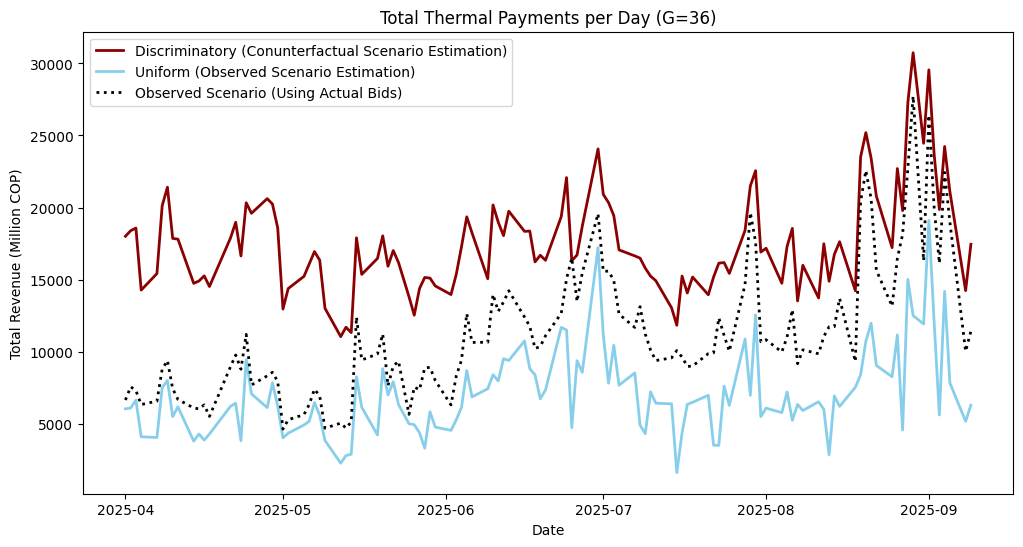

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    ingreso_por_dia_uniformeReal["Fecha"],
    ingreso_por_dia_discriminatorio["ingreso_total_dia"],
    color="darkred",
    label="Discriminatory (Conunterfactual Scenario Estimation)",
    linewidth=2
)

plt.plot(
    ingreso_por_dia_uniformeReal["Fecha"],
    ingreso_por_dia_uniforme["ingreso_total_dia"],
    color="skyblue",
    label="Uniform (Observed Scenario Estimation)",
    linewidth=2
)

plt.plot(
    ingreso_por_dia_uniformeReal["Fecha"],
    ingreso_por_dia_uniformeReal["ingreso_total_dia"],
    color="black",
    linestyle=":",
    label="Observed Scenario (Using Actual Bids)",
    linewidth=2
)

plt.legend()
plt.title(f'Total Thermal Payments per Day (G={G})')
plt.xlabel("Date")
plt.ylabel("Total Revenue (Million COP)")
plt.savefig(f'symmetric/{G}redes{estadistica}/payment_comparison_{T}.png', dpi=300, bbox_inches='tight')
plt.show()